# Beyond FC: which connectivity measure makes the best attention?

`custom_attention_construction.ipynb` replaced every same-time-patch block of the attention
matrix with the subject's Pearson correlation matrix (FC). Pearson is only one way to measure
coupling between two BOLD signals, and it only sees instantaneous linear covariation.

This notebook swaps in other region x region measures and asks two questions:

1. **Which measure looks most like real attention?** Structural comparison, no model involved.
2. **Which measure works best as attention?** Zero-shot masked-patch reconstruction, same
   protocol as `custom_attention_zero_shot.ipynb`.

The measures, in `connectivity_measures.py`:

| measure | what it adds over Pearson |
|---|---|
| pearson (FC) | baseline |
| spearman | monotone non-linear coupling, outlier-robust |
| partial correlation | direct coupling, with other regions regressed out |
| mutual information | Gaussian-copula MI, invariant to monotone rescaling |
| phase locking (PLV) | phase synchrony, amplitude ignored |
| phase lag index (PLI) | lead-lag phase relations, zero-lag coupling ignored |
| granger causality | **directed** -- does i's past help forecast j? |
| structural connectivity | anatomical wiring; identical for every subject, no BOLD at all |
| **random (baseline)** | **control**: random values in the blocks -- no structure at all |
| **uniform (baseline)** | **control**: every pair equal, so attention spreads evenly within each block |
| o-information | multivariate redundancy vs synergy, averaged over third regions |

The last two rows of the table matter for a reason worth stating up front: real attention is
**asymmetric**, while Pearson FC is symmetric by construction. A directed measure can express
something the FC hypothesis structurally cannot.

In [1]:
import os
import sys
import csv

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

torch.set_num_threads(MAX_CPU_THREADS)
sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data
from connectivity_measures import MEASURES, SYMMETRIC
from custom_attention import (token_region_patch, fc_block_mask, noise_schedule,
                              build_custom_attention, make_custom_attention_hook, region_lag_profile,
                              install_decoder_attention, restore_decoder_attention)

get_ipython().run_line_magic("matplotlib", "inline")

In [2]:
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO, SUBFOLDER = "vandijklab/brainlm", "old_13M"

WINDOW_SIZE = 200
N_SUBJECTS = 10           # zero-shot runs 1 + len(MEASURES) models per subject per condition
RANDOM_SEED = 0
NOISE_START_FRACTION = 2 / 3

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()
spatial_coords = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
num_layers = config.num_hidden_layers
FUTURE_PATCH = num_patches - 1
regions, patches = token_region_patch(num_regions, num_patches)

# One masked patch per region -> exactly num_regions masked tokens.
model.config.mask_ratio = num_regions / seq_len

# The decoder has its own attention layers and is where masked tokens actually get filled in.
# With REPLACE_DECODER the noise schedule spans every attention layer in the model (encoder +
# decoder), so the deepest decoder layer is the noise-free one rather than the last encoder layer.
REPLACE_DECODER = True
num_decoder_layers = len(model.decoder.decoder_layers)
n_attention_layers = num_layers + (num_decoder_layers if REPLACE_DECODER else 0)
print(f"replacing {num_layers} encoder + {num_decoder_layers if REPLACE_DECODER else 0} decoder "
      f"attention layers ({n_attention_layers} total)")
block_mask = fc_block_mask(patches)

with h5py.File(INPUT_H5, "r") as f:
    all_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]

print(f"{num_regions} regions, {num_patches} patches, {num_layers} layers, {len(MEASURES)} measures")

/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


replacing 4 encoder + 2 decoder attention layers (6 total)


424 regions, 10 patches, 4 layers, 12 measures


## Compute every measure for one subject

In [4]:
def load_subject(subject_index):
    with h5py.File(INPUT_H5, "r") as f:
        sub_id = f["subject_ids"][subject_index].decode("utf-8")
        raw = f["parcel_ts"][subject_index, :, :]
    x = preprocess_subject_data(raw, num_windows=3, window_size=WINDOW_SIZE)[0:1]
    return sub_id, x.to(device), raw[:WINDOW_SIZE, :].T


def real_attention_per_layer(x):
    identity_noise = (torch.arange(seq_len, dtype=torch.float32) / seq_len).unsqueeze(0).to(device)
    original = model.config.mask_ratio
    model.config.mask_ratio = 0.0
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=identity_noise)
    finally:
        model.config.mask_ratio = original
    return [a[0].mean(dim=0).cpu().numpy()[1:, 1:] for a in out.attentions]


sub_id, x_demo, window_demo = load_subject(0)
real_attn = real_attention_per_layer(x_demo)

measures = {name: fn(window_demo) for name, fn in MEASURES.items()}
for name, matrix in measures.items():
    asymmetry = np.abs(matrix - matrix.T).mean()
    print(f"{name:22s} range=[{matrix.min():7.3f}, {matrix.max():6.3f}]  "
          f"mean|.|={np.abs(matrix).mean():.4f}  asymmetry={asymmetry:.4f}"
          f"{'' if name in SYMMETRIC else '   <- directed'}")

pearson (FC)           range=[ -0.455,  1.000]  mean|.|=0.1266  asymmetry=0.0000
spearman               range=[ -0.461,  1.000]  mean|.|=0.1244  asymmetry=0.0000
partial correlation    range=[ -0.159,  1.000]  mean|.|=0.0305  asymmetry=0.0000
mutual information     range=[  0.000,  0.667]  mean|.|=0.0160  asymmetry=0.0000
phase locking (PLV)    range=[  0.001,  1.000]  mean|.|=0.1453  asymmetry=0.0000
phase lag index (PLI)  range=[  0.000,  1.000]  mean|.|=0.1019  asymmetry=0.0000
granger causality      range=[  0.000,  0.247]  mean|.|=0.0098  asymmetry=0.0120   <- directed
structural connectivity range=[  0.000,  0.996]  mean|.|=0.0512  asymmetry=0.0000
o-information (synergy) range=[ -0.147,  0.000]  mean|.|=0.0127  asymmetry=0.0000
o-information (redundancy) range=[ -0.000,  0.414]  mean|.|=0.0126  asymmetry=0.0000
random (baseline)      range=[ -3.246,  3.030]  mean|.|=0.5623  asymmetry=0.0000
uniform (baseline)     range=[  1.000,  1.000]  mean|.|=1.0000  asymmetry=0.0000


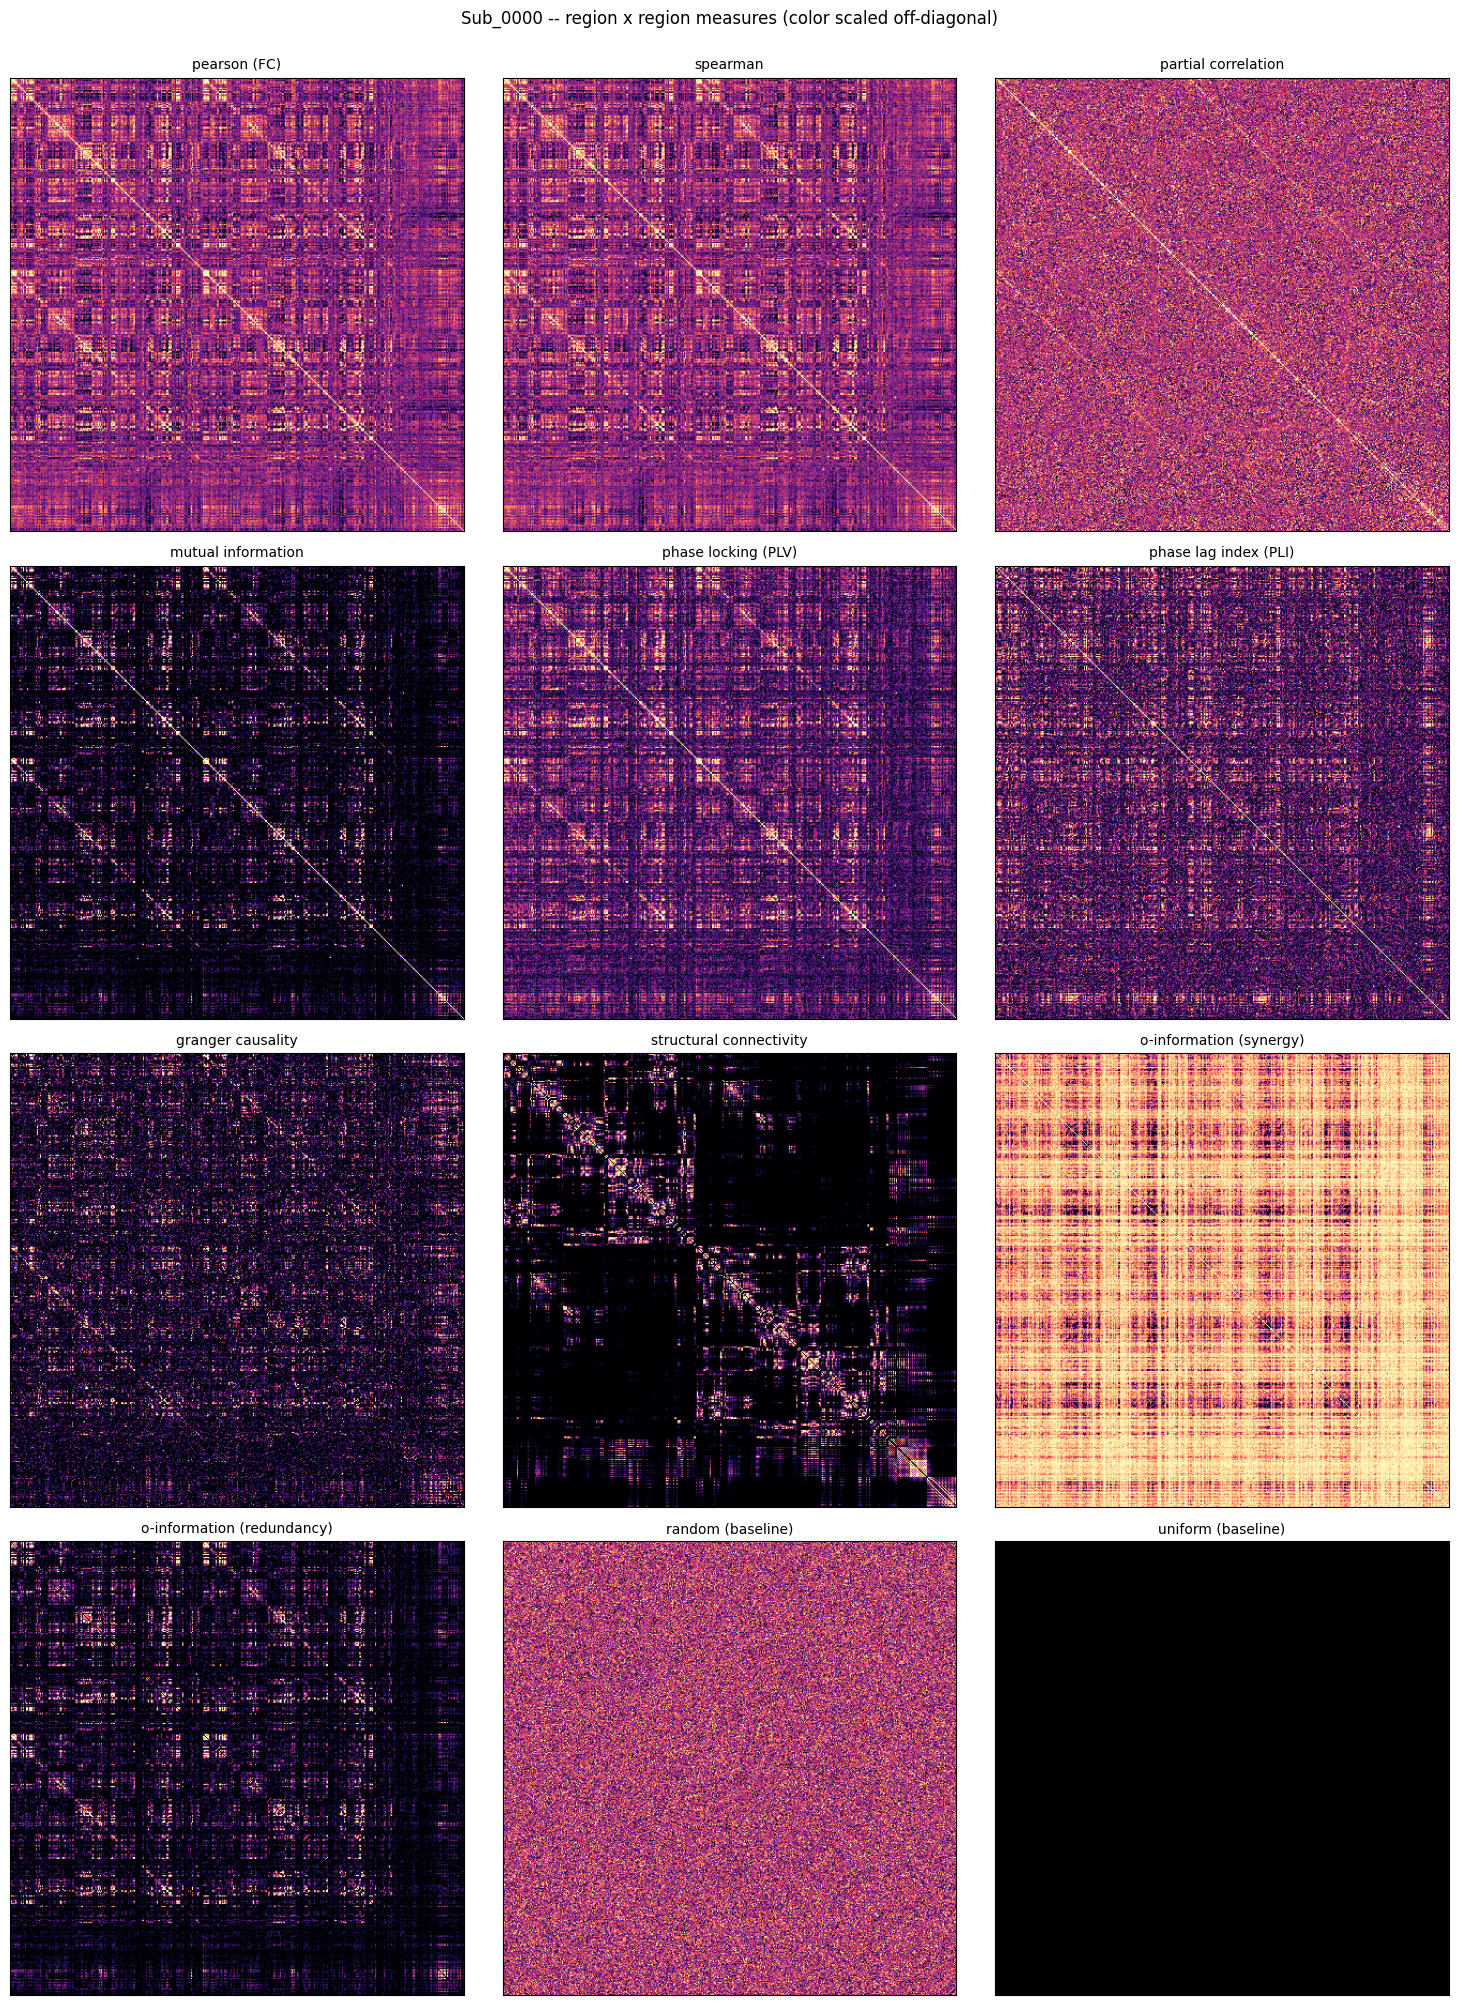

In [5]:
n_cols = 3
n_rows = -(-len(measures) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
for ax in axes.ravel()[len(measures):]:
    ax.axis("off")
for ax, (name, matrix) in zip(axes.ravel(), measures.items()):
    off = matrix[~np.eye(num_regions, dtype=bool)]
    ax.imshow(matrix, cmap="magma", vmin=np.percentile(off, 1), vmax=np.percentile(off, 99))
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{sub_id} -- region x region measures (color scaled off-diagonal)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_connectivity_measures.png"), dpi=130, bbox_inches="tight")
plt.show()

## How much do the measures actually differ?

If two measures rank region pairs almost identically they will build almost identical attention,
so this says which comparisons below are genuinely independent.

/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


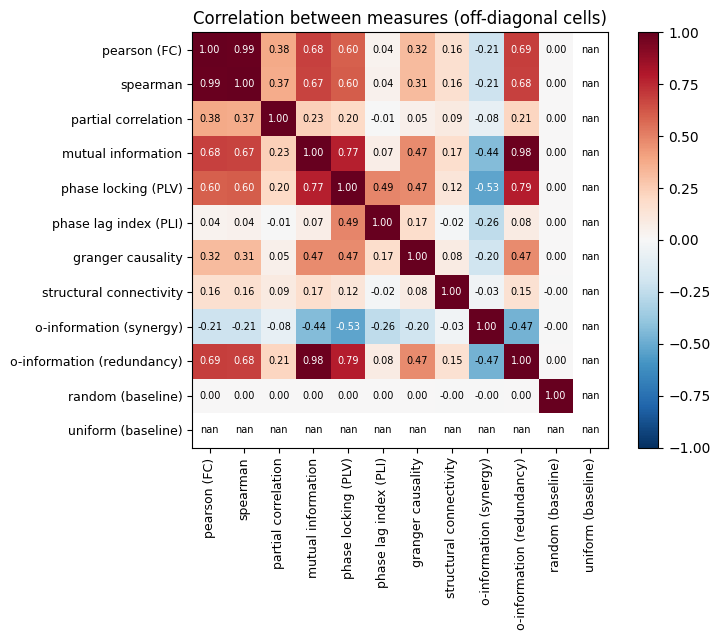

In [6]:
names = list(measures)
off_diag = ~np.eye(num_regions, dtype=bool)
similarity = np.array([[np.corrcoef(measures[a][off_diag], measures[b][off_diag])[0, 1]
                        for b in names] for a in names])

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(similarity, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=9)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(similarity[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Correlation between measures (off-diagonal cells)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_measure_similarity.png"), dpi=130, bbox_inches="tight")
plt.show()

## Which measure looks most like real attention?

Each measure is dropped into the same construction -- measure in the grid-diagonal blocks, noise
elsewhere, noise shrinking to zero by the last layer -- and compared against the model's real
attention. No model forward pass is involved in building these, so any agreement comes from the
measure itself.

pearson (FC)           L0= 0.006  L1= 0.333  L2= 0.111  L3= 0.619


spearman               L0= 0.006  L1= 0.331  L2= 0.110  L3= 0.617


partial correlation    L0=-0.002  L1= 0.183  L2= 0.079  L3= 0.519


mutual information     L0= 0.007  L1= 0.353  L2= 0.107  L3= 0.551


phase locking (PLV)    L0= 0.006  L1= 0.306  L2= 0.107  L3= 0.633


...

structural connectivity L0=-0.005  L1= 0.273  L2= 0.100  L3= 0.554


o-information (synergy) L0= 0.010  L1= 0.248  L2= 0.082  L3= 0.542


o-information (redundancy) L0= 0.008  L1= 0.360  L2= 0.105  L3= 0.551


random (baseline)      L0= 0.001  L1= 0.177  L2= 0.069  L3= 0.481


uniform (baseline)     L0= 0.001  L1= 0.222  L2= 0.092  L3= 0.615


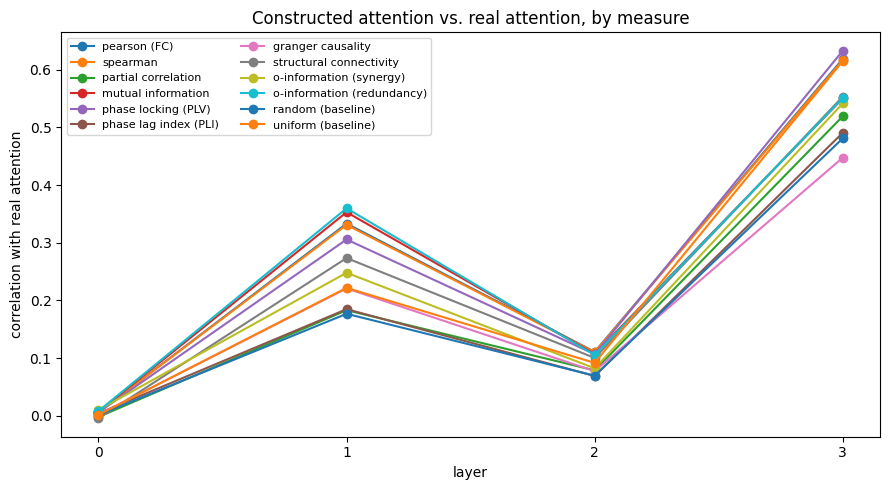

In [7]:
def build_layers(matrix):
    scales = noise_schedule(float(np.abs(matrix).mean()), num_layers, NOISE_START_FRACTION)
    rng = np.random.default_rng(RANDOM_SEED)
    return [build_custom_attention(matrix, regions, patches, scales[layer], rng) for layer in range(num_layers)]


constructions = {name: build_layers(matrix) for name, matrix in measures.items()}
off_diag_full = ~np.eye(seq_len, dtype=bool)

fig, ax = plt.subplots(figsize=(9, 5))
for name, layers in constructions.items():
    corr = [np.corrcoef(real_attn[layer][off_diag_full], layers[layer][off_diag_full])[0, 1]
            for layer in range(num_layers)]
    ax.plot(range(num_layers), corr, marker="o", label=name)
    print(f"{name:22s} " + "  ".join(f"L{l}={c:6.3f}" for l, c in enumerate(corr)))

ax.set_xlabel("layer"); ax.set_ylabel("correlation with real attention")
ax.set_xticks(range(num_layers))
ax.set_title("Constructed attention vs. real attention, by measure")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_measure_vs_real_attention.png"), dpi=130, bbox_inches="tight")
plt.show()

### Across subjects

The plot above is one subject. This repeats it for `N_SUBJECTS_VIOLIN` subjects so each measure
gets a distribution rather than a single line, with one panel per layer. Slow -- it needs a
forward pass plus all nine measures per subject.

In [8]:
N_SUBJECTS_VIOLIN = 25

records = []
for subject_index in range(N_SUBJECTS_VIOLIN):
    sid, x_s, window_s = load_subject(subject_index)
    if np.isnan(window_s).any():
        print(f"{sid}: skipped (NaNs)")
        continue
    real_s = real_attention_per_layer(x_s)
    for name, fn in MEASURES.items():
        matrix = fn(window_s)
        scales = noise_schedule(float(np.abs(matrix).mean()), num_layers, NOISE_START_FRACTION)
        rng = np.random.default_rng(RANDOM_SEED)
        for layer in range(num_layers):
            constructed = build_custom_attention(matrix, regions, patches, scales[layer], rng)
            r = np.corrcoef(real_s[layer][off_diag_full], constructed[off_diag_full])[0, 1]
            records.append({"subject_id": sid, "measure": name, "layer": layer, "r": float(r)})
    print(f"{sid} done")

csv_path = os.path.join(OUTPUTS_DIR, "measure_vs_real_attention_by_subject.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["subject_id", "measure", "layer", "r"])
    writer.writeheader(); writer.writerows(records)
print(f"\n{len(records)} rows -> {csv_path}")

Sub_0000 done


Sub_0001 done


Sub_0002 done


Sub_0004 done


Sub_0005 done


...

Sub_0021 done


Sub_0022 done


Sub_0023 done


Sub_0024 done


Sub_0025 done

1200 rows -> outputs/measure_vs_real_attention_by_subject.csv


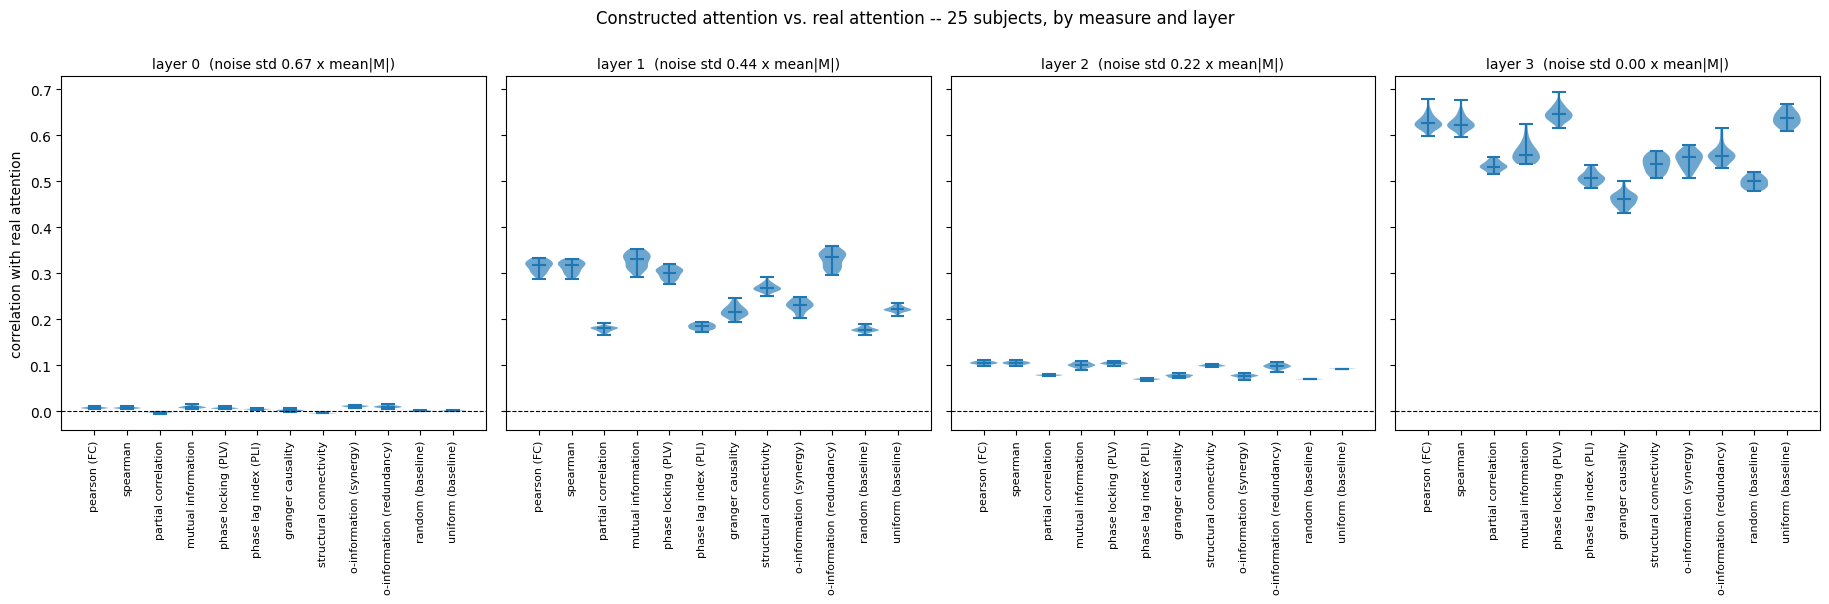

measure                   layer 0        layer 1        layer 2        layer 3      
pearson (FC)              +0.007+-0.002  +0.315+-0.012  +0.105+-0.003  +0.628+-0.016
spearman                  +0.007+-0.002  +0.314+-0.013  +0.104+-0.003  +0.626+-0.016
partial correlation       -0.003+-0.001  +0.179+-0.005  +0.078+-0.001  +0.532+-0.010
mutual information        +0.009+-0.002  +0.327+-0.017  +0.100+-0.005  +0.563+-0.021
phase locking (PLV)       +0.006+-0.002  +0.300+-0.012  +0.104+-0.003  +0.647+-0.016
phase lag index (PLI)     +0.004+-0.001  +0.184+-0.006  +0.069+-0.001  +0.507+-0.012
granger causality         +0.001+-0.002  +0.217+-0.012  +0.076+-0.003  +0.460+-0.015
structural connectivity   -0.004+-0.000  +0.268+-0.009  +0.099+-0.002  +0.538+-0.017
o-information (synergy)   +0.010+-0.002  +0.229+-0.012  +0.076+-0.004  +0.547+-0.018
o-information (redundancy)  +0.010+-0.003  +0.330+-0.018  +0.098+-0.005  +0.558+-0.019
random (baseline)         +0.001+-0.001  +0.177+-0.005  +0.070+

In [9]:
names = list(MEASURES)
n_subj = len({rec["subject_id"] for rec in records})

fig, axes = plt.subplots(1, num_layers, figsize=(4.6 * num_layers, 6), sharey=True)
for layer, ax in enumerate(axes):
    data = [[rec["r"] for rec in records if rec["measure"] == nm and rec["layer"] == layer]
            for nm in names]
    parts = ax.violinplot(data, showmedians=True, widths=0.85)
    for body in parts["bodies"]:
        body.set_alpha(0.65)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_title(f"layer {layer}  (noise std {noise_schedule(1.0, num_layers, NOISE_START_FRACTION)[layer]:.2f} x mean|M|)",
                 fontsize=10)
axes[0].set_ylabel("correlation with real attention")
fig.suptitle(f"Constructed attention vs. real attention -- {n_subj} subjects, by measure and layer", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "measure_vs_real_attention_violin.png"), dpi=130, bbox_inches="tight")
plt.show()

print(f"{'measure':24s}" + "".join(f"  layer {l}      " for l in range(num_layers)))
for nm in names:
    row = "".join(
        f"  {np.mean([r['r'] for r in records if r['measure']==nm and r['layer']==l]):+.3f}"
        f"+-{np.std([r['r'] for r in records if r['measure']==nm and r['layer']==l]):.3f}"
        for l in range(num_layers))
    print(f"{nm:24s}{row}")

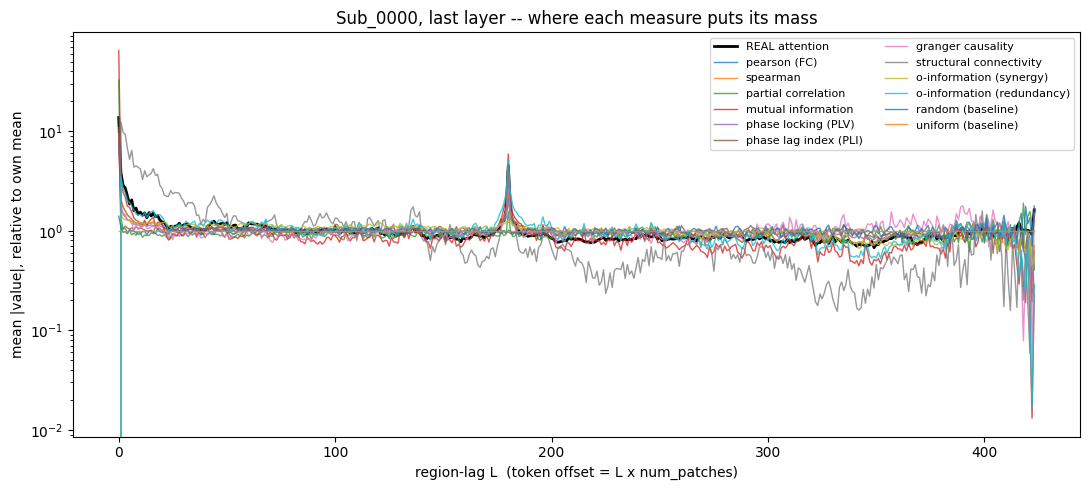

In [10]:
max_lag = num_regions
fig, ax = plt.subplots(figsize=(11, 5))
profile = region_lag_profile(real_attn[-1], num_patches, max_lag)
ax.semilogy(profile / profile.mean(), color="black", linewidth=2, label="REAL attention")
for name, layers in constructions.items():
    profile = region_lag_profile(layers[-1], num_patches, max_lag)
    ax.semilogy(profile / profile.mean(), linewidth=1, alpha=0.8, label=name)
ax.set_xlabel("region-lag L  (token offset = L x num_patches)")
ax.set_ylabel("mean |value|, relative to own mean")
ax.set_title(f"{sub_id}, last layer -- where each measure puts its mass")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_measure_region_lag_profiles.png"), dpi=130, bbox_inches="tight")
plt.show()

## Zero-shot: which measure works best *as* attention?

Same protocol as `custom_attention_zero_shot.ipynb` -- one masked 20-TR patch per region, scored
by Pearson r against the real signal, with identical masked tokens across every model so the
comparisons are paired. `original` leaves attention untouched.

In [11]:
def exact_mask_noise(mask_token_indices):
    noise = torch.rand(1, seq_len, device=device)
    idx = torch.as_tensor(mask_token_indices, device=device, dtype=torch.long).unsqueeze(0)
    noise.scatter_(1, idx, 1.0 + torch.rand(1, idx.shape[1], device=device))
    return noise


def predict(x, mask_token_indices, matrix, subject_index):
    """matrix=None leaves attention untouched; otherwise it fills the grid-diagonal blocks."""
    noise = exact_mask_noise(mask_token_indices)
    handles, decoder_handles = [], []
    if matrix is not None:
        with torch.no_grad():
            _, _, ids_restore = model.vit.embeddings(x, spatial_coords, noise)
        len_keep = seq_len - len(mask_token_indices)
        kept = torch.argsort(ids_restore, dim=1)[0, :len_keep].cpu().numpy()
        kept_regions, kept_patches = kept // num_patches, kept % num_patches
        scales = noise_schedule(float(np.abs(matrix).mean()), n_attention_layers, NOISE_START_FRACTION)

        # encoder: only the kept tokens are in the sequence
        for layer in range(num_layers):
            rng = np.random.default_rng(RANDOM_SEED + subject_index * 1000 + layer)
            custom = build_custom_attention(matrix, kept_regions, kept_patches, scales[layer], rng)
            handles.append(model.vit.encoder.layer[layer].attention.self.register_forward_hook(
                make_custom_attention_hook(custom)))

        # decoder: mask tokens are back, so the matrices cover every token
        if REPLACE_DECODER:
            decoder_matrices = []
            for d in range(num_decoder_layers):
                rng = np.random.default_rng(RANDOM_SEED + subject_index * 1000 + num_layers + d)
                decoder_matrices.append(
                    build_custom_attention(matrix, regions, patches, scales[num_layers + d], rng))
            decoder_handles = install_decoder_attention(model, decoder_matrices)
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)
    finally:
        for handle in handles:
            handle.remove()
        restore_decoder_attention(decoder_handles)

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits
    predicted = logits[0].detach().cpu().numpy()
    masked = out.mask[0].detach().cpu().numpy().astype(bool)

    expected = {(i // num_patches, i % num_patches) for i in mask_token_indices}
    if {tuple(rc) for rc in np.argwhere(masked)} != expected:
        raise RuntimeError("the model masked a different token set than requested "
                           "-- check model.config.mask_ratio")
    return predicted, masked


def per_region_correlation(predicted, masked, window):
    r_values = np.full(num_regions, np.nan)
    for region in range(num_regions):
        patch = int(np.flatnonzero(masked[region])[0])
        lo, hi = patch * patch_size, (patch + 1) * patch_size
        r_values[region] = np.corrcoef(window[region, lo:hi], predicted[region, patch, :])[0, 1]
    return r_values

In [12]:
results = []
for subject_index in range(N_SUBJECTS):
    sid, x, window = load_subject(subject_index)
    if np.isnan(window).any():
        print(f"{sid}: skipped (NaNs)")
        continue

    subject_measures = {"original": None}
    subject_measures.update({name: fn(window) for name, fn in MEASURES.items()})

    rng = np.random.default_rng(RANDOM_SEED + subject_index)
    conditions = {"future": [r * num_patches + FUTURE_PATCH for r in range(num_regions)],
                  "random": [r * num_patches + int(p) for r, p in
                             enumerate(rng.integers(0, num_patches, size=num_regions))]}

    summary = []
    for condition, mask_indices in conditions.items():
        for name, matrix in subject_measures.items():
            predicted, masked = predict(x, mask_indices, matrix, subject_index)
            r_values = per_region_correlation(predicted, masked, window)
            for region in range(num_regions):
                results.append({"subject_id": sid, "region": region, "condition": condition,
                                "measure": name, "r": float(r_values[region])})
            summary.append(f"{condition[:3]}/{name.split()[0]}={np.nanmean(r_values):.3f}")
    print(f"{sid}: " + " ".join(summary))

csv_path = os.path.join(OUTPUTS_DIR, "alternative_measures_zero_shot.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["subject_id", "region", "condition", "measure", "r"])
    writer.writeheader(); writer.writerows(results)
print(f"\n{len(results)} rows -> {csv_path}")

Sub_0000: fut/original=-0.016 fut/pearson=-0.037 fut/spearman=-0.037 fut/partial=-0.035 fut/mutual=-0.044 fut/phase=-0.038 fut/phase=-0.038 fut/granger=-0.040 fut/structural=-0.033 fut/o-information=-0.039 fut/o-information=-0.039 fut/random=-0.038 fut/uniform=-0.037 ran/original=0.149 ran/pearson=0.136 ran/spearman=0.134 ran/partial=0.087 ran/mutual=0.170 ran/phase=0.110 ran/phase=0.067 ran/granger=0.130 ran/structural=0.123 ran/o-information=0.075 ran/o-information=0.173 ran/random=0.070 ran/uniform=0.069


Sub_0001: fut/original=-0.025 fut/pearson=-0.122 fut/spearman=-0.121 fut/partial=-0.125 fut/mutual=-0.131 fut/phase=-0.119 fut/phase=-0.116 fut/granger=-0.120 fut/structural=-0.117 fut/o-information=-0.107 fut/o-information=-0.121 fut/random=-0.119 fut/uniform=-0.119 ran/original=0.109 ran/pearson=0.114 ran/spearman=0.115 ran/partial=0.066 ran/mutual=0.138 ran/phase=0.101 ran/phase=0.064 ran/granger=0.124 ran/structural=0.102 ran/o-information=0.064 ran/o-information=0.143 ran/random=0.060 ran/uniform=0.063


Sub_0002: fut/original=0.235 fut/pearson=0.190 fut/spearman=0.180 fut/partial=0.184 fut/mutual=0.145 fut/phase=0.184 fut/phase=0.190 fut/granger=0.173 fut/structural=0.203 fut/o-information=0.203 fut/o-information=0.173 fut/random=0.198 fut/uniform=0.199 ran/original=0.039 ran/pearson=0.236 ran/spearman=0.239 ran/partial=0.208 ran/mutual=0.246 ran/phase=0.233 ran/phase=0.201 ran/granger=0.247 ran/structural=0.235 ran/o-information=0.203 ran/o-information=0.249 ran/random=0.203 ran/uniform=0.203


Sub_0004: fut/original=-0.043 fut/pearson=0.028 fut/spearman=0.028 fut/partial=0.029 fut/mutual=0.018 fut/phase=0.029 fut/phase=0.028 fut/granger=0.028 fut/structural=0.028 fut/o-information=0.031 fut/o-information=0.023 fut/random=0.034 fut/uniform=0.034 ran/original=0.251 ran/pearson=0.068 ran/spearman=0.067 ran/partial=0.032 ran/mutual=0.090 ran/phase=0.056 ran/phase=0.032 ran/granger=0.077 ran/structural=0.065 ran/o-information=0.039 ran/o-information=0.093 ran/random=0.030 ran/uniform=0.032


Sub_0005: fut/original=0.167 fut/pearson=-0.131 fut/spearman=-0.130 fut/partial=-0.116 fut/mutual=-0.141 fut/phase=-0.126 fut/phase=-0.113 fut/granger=-0.124 fut/structural=-0.107 fut/o-information=-0.114 fut/o-information=-0.140 fut/random=-0.112 fut/uniform=-0.111 ran/original=0.043 ran/pearson=0.198 ran/spearman=0.197 ran/partial=0.173 ran/mutual=0.196 ran/phase=0.190 ran/phase=0.157 ran/granger=0.218 ran/structural=0.186 ran/o-information=0.144 ran/o-information=0.201 ran/random=0.174 ran/uniform=0.172


...

Sub_0007: fut/original=0.011 fut/pearson=-0.066 fut/spearman=-0.067 fut/partial=-0.094 fut/mutual=-0.013 fut/phase=-0.075 fut/phase=-0.093 fut/granger=-0.075 fut/structural=-0.086 fut/o-information=-0.088 fut/o-information=-0.032 fut/random=-0.108 fut/uniform=-0.107 ran/original=0.196 ran/pearson=0.149 ran/spearman=0.149 ran/partial=0.095 ran/mutual=0.190 ran/phase=0.129 ran/phase=0.078 ran/granger=0.147 ran/structural=0.144 ran/o-information=0.077 ran/o-information=0.178 ran/random=0.073 ran/uniform=0.073


Sub_0008: fut/original=-0.015 fut/pearson=-0.159 fut/spearman=-0.160 fut/partial=-0.163 fut/mutual=-0.177 fut/phase=-0.157 fut/phase=-0.151 fut/granger=-0.159 fut/structural=-0.159 fut/o-information=-0.143 fut/o-information=-0.166 fut/random=-0.151 fut/uniform=-0.151 ran/original=0.171 ran/pearson=0.145 ran/spearman=0.146 ran/partial=0.094 ran/mutual=0.177 ran/phase=0.126 ran/phase=0.084 ran/granger=0.137 ran/structural=0.127 ran/o-information=0.084 ran/o-information=0.178 ran/random=0.082 ran/uniform=0.083


Sub_0009: fut/original=-0.039 fut/pearson=0.066 fut/spearman=0.067 fut/partial=0.070 fut/mutual=0.051 fut/phase=0.068 fut/phase=0.067 fut/granger=0.066 fut/structural=0.061 fut/o-information=0.066 fut/o-information=0.050 fut/random=0.068 fut/uniform=0.067 ran/original=0.185 ran/pearson=0.191 ran/spearman=0.191 ran/partial=0.140 ran/mutual=0.212 ran/phase=0.175 ran/phase=0.117 ran/granger=0.196 ran/structural=0.168 ran/o-information=0.119 ran/o-information=0.214 ran/random=0.129 ran/uniform=0.129


Sub_0010: fut/original=0.208 fut/pearson=-0.165 fut/spearman=-0.165 fut/partial=-0.164 fut/mutual=-0.187 fut/phase=-0.159 fut/phase=-0.145 fut/granger=-0.184 fut/structural=-0.145 fut/o-information=-0.127 fut/o-information=-0.179 fut/random=-0.147 fut/uniform=-0.149 ran/original=0.184 ran/pearson=0.121 ran/spearman=0.119 ran/partial=0.073 ran/mutual=0.147 ran/phase=0.108 ran/phase=0.063 ran/granger=0.151 ran/structural=0.125 ran/o-information=0.056 ran/o-information=0.144 ran/random=0.067 ran/uniform=0.067



110240 rows -> outputs/alternative_measures_zero_shot.csv


## Results

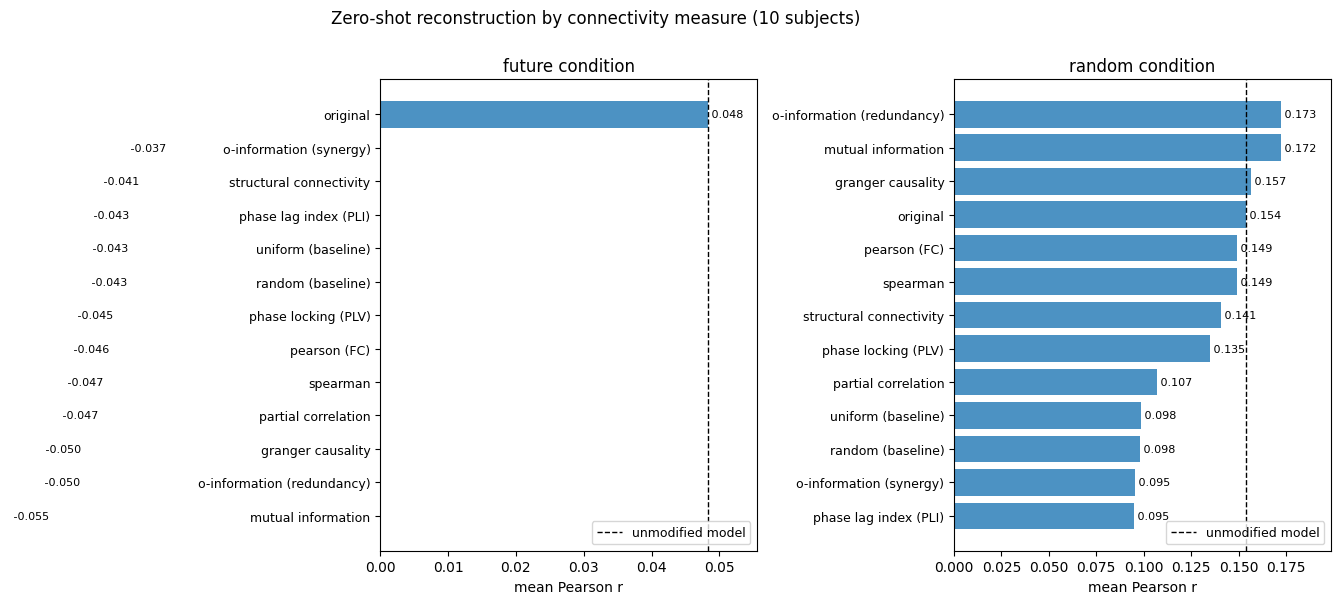

In [13]:
model_names = ["original"] + list(MEASURES)


def collect(condition, measure):
    return np.array([row["r"] for row in results
                     if row["condition"] == condition and row["measure"] == measure])


n_subj = len({row["subject_id"] for row in results})
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, condition in zip(axes, ["future", "random"]):
    means = np.array([np.nanmean(collect(condition, name)) for name in model_names])
    order = np.argsort(means)[::-1]
    labels, values = [model_names[i] for i in order], means[order]
    y = np.arange(len(order))
    ax.barh(y, values, color="tab:blue", alpha=0.8)
    for yi, v in zip(y, values):
        ax.text(v, yi, f" {v:.3f}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, values.max() * 1.15)
    ax.set_xlabel("mean Pearson r"); ax.set_title(f"{condition} condition")
    ax.axvline(means[model_names.index("original")], color="black", linestyle="--",
               linewidth=1, label="unmodified model")
    ax.legend(fontsize=9, loc="lower right")
fig.suptitle(f"Zero-shot reconstruction by connectivity measure ({n_subj} subjects)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "alternative_measures_zero_shot.png"), dpi=130, bbox_inches="tight")
plt.show()

In [14]:
for condition in ["future", "random"]:
    baseline = collect(condition, "original")
    print(f"\n{condition}:")
    ranked = sorted(model_names, key=lambda n: -np.nanmean(collect(condition, n)))
    for name in ranked:
        values = collect(condition, name)
        if name == "original":
            print(f"  {name:22s} mean={np.nanmean(values):.3f}   (baseline)")
            continue
        valid = ~(np.isnan(values) | np.isnan(baseline))
        _, p_value = stats.wilcoxon(values[valid], baseline[valid])
        better = "better" if np.nanmean(values) > np.nanmean(baseline) else "worse "
        print(f"  {name:22s} mean={np.nanmean(values):.3f}   {better} than original, p={p_value:.2g}")


future:
  original               mean=0.048   (baseline)
  o-information (synergy) mean=-0.037   worse  than original, p=2.5e-41
  structural connectivity mean=-0.041   worse  than original, p=3.3e-42
  phase lag index (PLI)  mean=-0.043   worse  than original, p=1.8e-44
  uniform (baseline)     mean=-0.043   worse  than original, p=9.3e-44
  random (baseline)      mean=-0.043   worse  than original, p=7.5e-44
  phase locking (PLV)    mean=-0.045   worse  than original, p=7.6e-45
  pearson (FC)           mean=-0.046   worse  than original, p=1.1e-44
  spearman               mean=-0.047   worse  than original, p=2.9e-45
  partial correlation    mean=-0.047   worse  than original, p=1.2e-46
  granger causality      mean=-0.050   worse  than original, p=1.1e-46
  o-information (redundancy) mean=-0.050   worse  than original, p=3.3e-47
  mutual information     mean=-0.055   worse  than original, p=9.8e-51

random:
  o-information (redundancy) mean=0.173   better than original, p=0.014


  mutual information     mean=0.172   better than original, p=0.019
  granger causality      mean=0.157   better than original, p=0.86
  original               mean=0.154   (baseline)
  pearson (FC)           mean=0.149   worse  than original, p=0.19
  spearman               mean=0.149   worse  than original, p=0.2
  structural connectivity mean=0.141   worse  than original, p=0.026
  phase locking (PLV)    mean=0.135   worse  than original, p=0.00083
  partial correlation    mean=0.107   worse  than original, p=1.2e-12
  uniform (baseline)     mean=0.098   worse  than original, p=1e-15
  random (baseline)      mean=0.098   worse  than original, p=8.2e-16
  o-information (synergy) mean=0.095   worse  than original, p=2.7e-16
  phase lag index (PLI)  mean=0.095   worse  than original, p=6.1e-17
